In [1]:
from ml_enhance import load_hpc_result, compare
from ml_enhance import CorrelationFilter
from ml_enhance import FeatureImportance
from sklearn.base import BaseEstimator
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np

In [4]:
# KRR_topo_relevant_no_norm_df = load_hpc_result(Path("../data/KRR_results/1_KRR_topo_relevant_no_norm_results.pkl"), "KRR_topo_relevant_no_norm")
# KRR_combo_relevant_no_norm_df = load_hpc_result(Path("../data/KRR_results/1_KRR_combo_relevant_no_norm_results.pkl"), "KRR_topo+QM_relevant_no_norm")

In [5]:
def combine_dfs(dfs: list[pd.DataFrame]) -> pd.DataFrame:
    r2_df = pd.concat([df[["name", "test_r2"]] for df in dfs])

    r2_df["group"] = r2_df["name"].str.extract(r"^(HuberReg|KRR|RF)")
    r2_df["variant"] = r2_df["name"].str.extract(r"_(topo\+QM|topo)")

    r2_df["variant"] = r2_df["variant"].replace({
        "topo": "Topo",
        "topo+QM": "Topo+QM"
    })

    return r2_df

In [6]:
def plot_performance(r2_df: pd.DataFrame) -> None:
    order = (
        r2_df.groupby("group")["test_r2"]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    palette = {
        "Topo": "lightgray",
        "Topo+QM": "tab:blue"
    }

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        data=r2_df,
        y="test_r2",
        x="group",
        order=order,
        palette=palette,
        hue="variant",
        width=0.6,
        fliersize=0
    )

    sns.pointplot(
        data=r2_df,
        y="test_r2",
        x="group",
        hue="variant",
        palette={"Topo": "tab:red", "Topo+QM": "tab:red"},
        order=order,
        dodge=0.3,
        linestyles="None",
        color="tab:red",
        markers="D",
        alpha=0.6
    )

    sns.stripplot(data=r2_df, x="group", y="test_r2", hue="variant", dodge=True, palette="dark:black", alpha=0.4)

    strip_handle = mlines.Line2D(
        [], [],
        color="black",
        marker="o",
        linestyle="None",
        markersize=6,
        alpha=0.4,
        label="Individual points"
    )

    point_handle = mlines.Line2D(
        [], [],
        color="tab:red",
        alpha=0.6,
        marker="D",
        linestyle="None",
        markersize=8,
        label="Mean ± SD"
    )

    legend_elements = [
        Patch(facecolor="tab:blue", edgecolor="black", label="QM + Topology"),
        Patch(facecolor="lightgray", edgecolor="black", label="Topology"),
    ]

    sns.despine(trim=False, left=False)

    plt.legend(handles=legend_elements+[point_handle, strip_handle], loc="lower left", frameon=False, fontsize=12)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("")
    plt.ylabel(r"$R^2$ score", fontsize=16)
    plt.title("Model performance comparison", fontsize=16)
    plt.ylim(0.74, 0.9)

In [7]:
def process_FI_data(fi_data: pd.DataFrame) -> dict[int, pd.Series]:
    groups = fi_data[["fold_id", "feature", "r2_mean"]]
    return {
        int(fold_id): df.set_index("feature")["r2_mean"]
        for fold_id, df in groups.groupby("fold_id")
    }

In [10]:
from math import floor

n_tot = 8759 # 8763 before rerun
n_train = floor(n_tot * (4/5))
n_test = n_tot - n_train

### Unfiltered feature set

In [11]:
HuberReg_combo_df = load_hpc_result(Path("../data/HuberReg_results/1_HuberReg_combo_rerun_results.pkl"), "HuberReg_topo+QM")
HuberReg_topo_df = load_hpc_result(Path("../data/HuberReg_results/1_HuberReg_topo_rerun_results.pkl"), "HuberReg_topo")

In [12]:
KRR_combo_df = load_hpc_result(Path("../data/KRR_results/1_KRR_combo_rerun_results.pkl"), "KRR_topo+QM")
KRR_topo_df = load_hpc_result(Path("../data/KRR_results/1_KRR_topo_rerun_results.pkl"), "KRR_topo")

In [13]:
RF_topo_df = load_hpc_result(Path("../data/RF_results/1_RF_topo_results.pkl"), "RF_topo")
RF_combo_df = load_hpc_result(Path("../data/RF_results/1_RF_combo_results.pkl"), "RF_topo+QM")

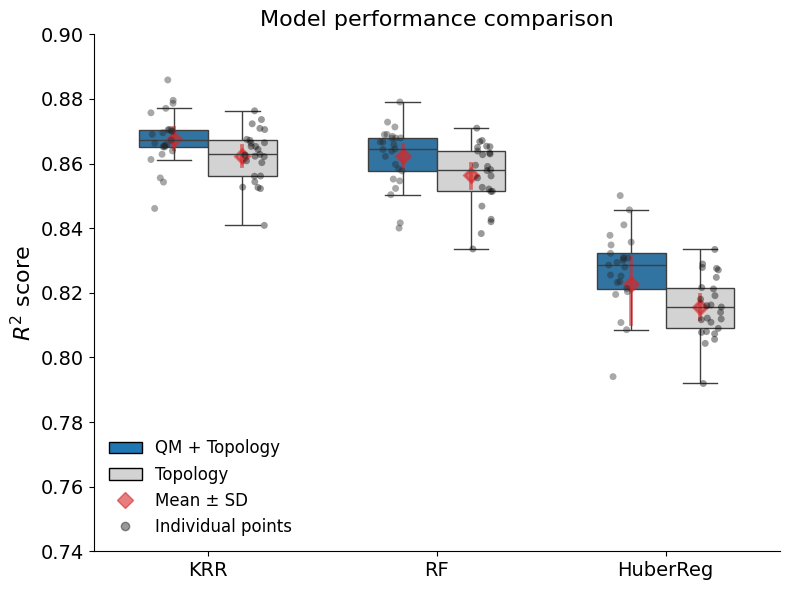

In [14]:
r2_df = combine_dfs([
        HuberReg_combo_df,
        HuberReg_topo_df,
        KRR_combo_df,
        KRR_topo_df,
        RF_topo_df,
        RF_combo_df
    ])

plot_performance(r2_df)
plt.tight_layout()
plt.show()

In [47]:
result = (
    r2_df
    .groupby("name")["test_r2"]
    .agg(["mean", "std"])
    .reset_index()
)
result

,name,mean,std
0,HuberReg_topo,0.815676,0.009518
1,HuberReg_topo+QM,0.822584,0.026762
2,KRR_topo,0.862488,0.008078
3,KRR_topo+QM,0.867672,0.008379
4,RF_topo,0.856424,0.009773
5,RF_topo+QM,0.862304,0.009295


In [15]:
compare(HuberReg_combo_df, HuberReg_topo_df, n_train=n_train, n_test=n_test)

HuberReg_topo+QM mean r2: 0.8225844602530548 (Train: 0.845893321631955)
HuberReg_topo mean r2: 0.815675707766128 (Train: 0.8275717079136661)
Mean improvement: 0.006908752486926999
T-test p-value: 0.1941960615751519 -> not statistically significant
Wilcoxon p-value: 0.0001398921012878418 -> statistically significant


HuberReg_topo+QM mean MSE: 0.9442052351843386 (Train: 0.8211122659332841)
HuberReg_topo mean MSE: 0.98119024673991 (Train: 0.9187565081836431)
Mean improvement: -0.03698501155557135
T-test p-value: 0.18726913865624661 -> not statistically significant
Wilcoxon p-value: 0.0001398921012878418 -> statistically significant




In [16]:
compare(KRR_combo_df, KRR_topo_df, n_train=n_train, n_test=n_test)

KRR_topo+QM mean r2: 0.8676719915058656 (Train: 0.9669099660169083)
KRR_topo mean r2: 0.8624876250542962 (Train: 0.9453246568437613)
Mean improvement: 0.005184366451569362
T-test p-value: 1.8567662483093272e-06 -> statistically significant
Wilcoxon p-value: 8.344650268554688e-07 -> statistically significant


KRR_topo+QM mean MSE: 0.7042758428775809 (Train: 0.17631152529205582)
KRR_topo mean MSE: 0.7318278277516194 (Train: 0.2913248169761584)
Mean improvement: -0.027551984874038555
T-test p-value: 1.7482195566742575e-06 -> statistically significant
Wilcoxon p-value: 8.344650268554688e-07 -> statistically significant




In [17]:
compare(RF_combo_df, RF_topo_df, n_train=n_train, n_test=n_test)

RF_topo+QM mean r2: 0.8623037272382387 (Train: 0.9614793577591161)
RF_topo mean r2: 0.8564244692856381 (Train: 0.9556470264673662)
Mean improvement: 0.005879257952600514
T-test p-value: 1.219424561327287e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


RF_topo+QM mean MSE: 0.7325815240597118 (Train: 0.20516033979207937)
RF_topo mean MSE: 0.7638501960123766 (Train: 0.2362241649982972)
Mean improvement: -0.03126867195266477
T-test p-value: 1.2135403792967736e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [20]:
huber_data = pd.read_csv(r"..\data\HuberReg_results\1_HuberReg_combo_rerun_PFI_results.csv")
huber_FI_dict = process_FI_data(huber_data)

huber_FI = FeatureImportance(HuberReg_combo_df, provided_FI=huber_FI_dict)
huber_fi_df = huber_FI.get_feature_importance(20)



krr_data = pd.read_csv(r"..\data\KRR_results\1_KRR_combo_rerun_PFI_results.csv")
krr_FI_dict = process_FI_data(krr_data)

krr_FI = FeatureImportance(KRR_combo_df, provided_FI=krr_FI_dict)
krr_fi_df = krr_FI.get_feature_importance(20)



# rf_data = pd.read_csv(r"..\data\RF_results\1_RF_combo_rerun_PFI_results.csv")
rf_data = pd.read_csv(r"..\data\RF_results\1_RF_combo_PFI_results.csv")
rf_FI_dict = process_FI_data(rf_data)

rf_FI = FeatureImportance(RF_combo_df, provided_FI=rf_FI_dict)
rf_fi_df = rf_FI.get_feature_importance(20)

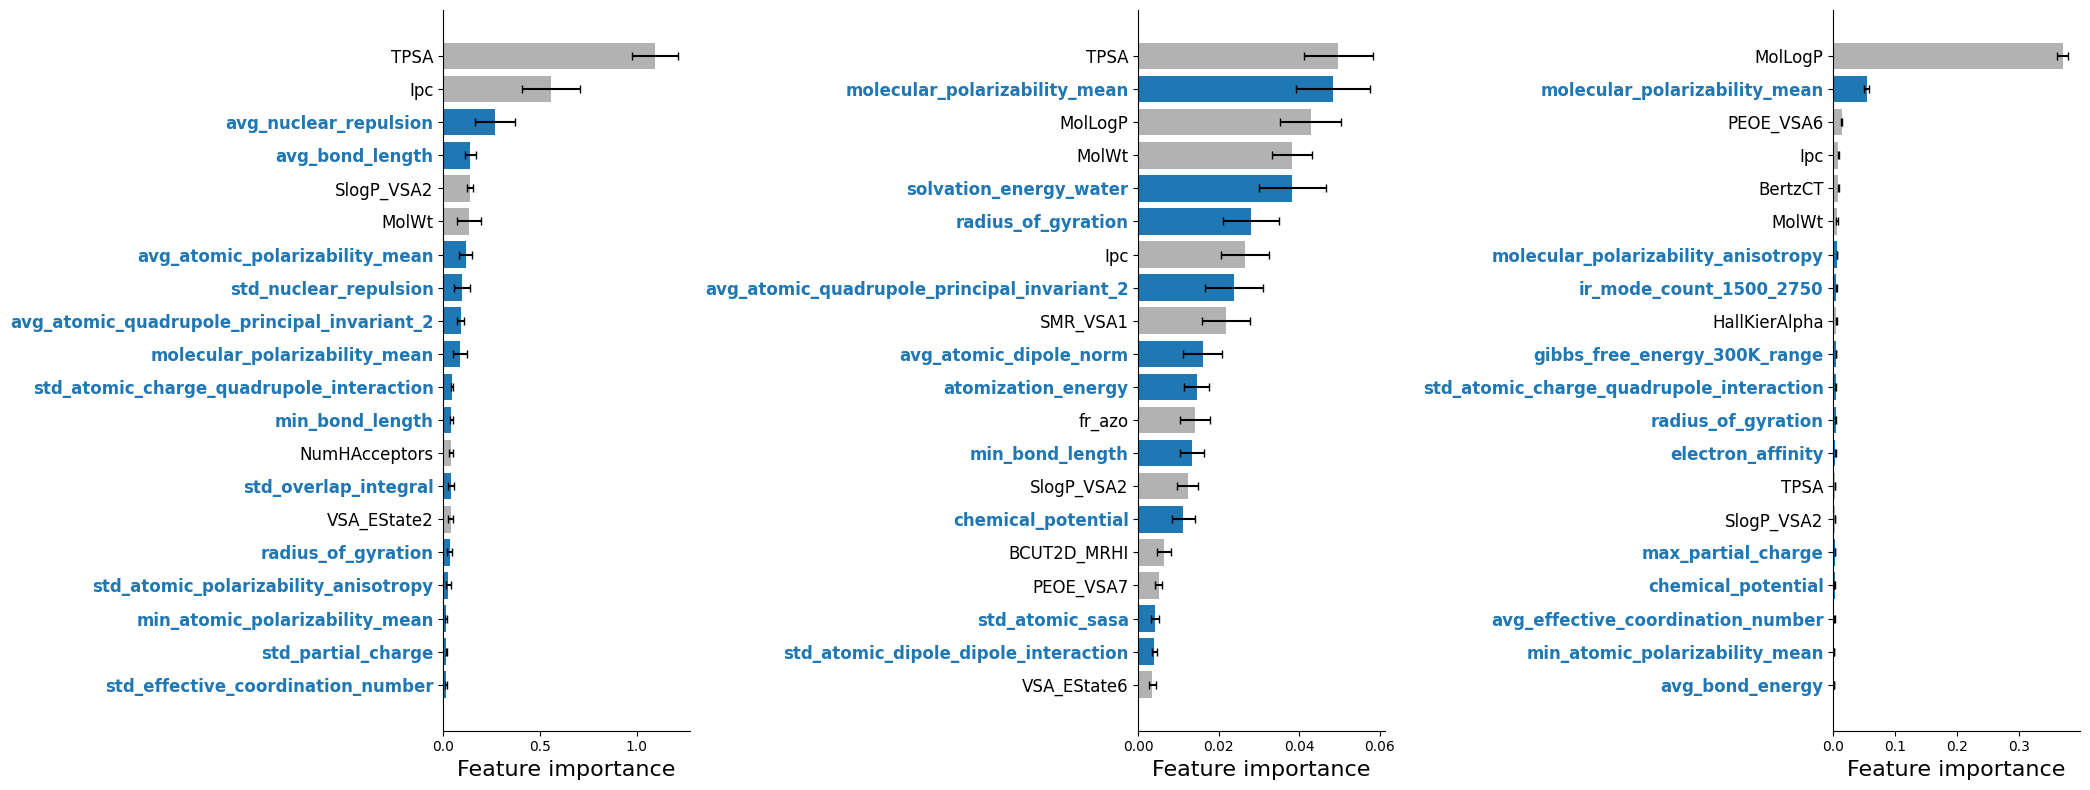

In [21]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 8))

huber_FI.plot(ax1)
krr_FI.plot(ax2)
rf_FI.plot(ax3)

plt.tight_layout()
plt.show()

### Only relevant features

In [22]:
HuberReg_combo_relevant_df = load_hpc_result(Path("../data/HuberReg_results/1_HuberReg_combo_relevant_rerun_results.pkl"), "HuberReg_topo+QM_relevant")
HuberReg_topo_relevant_df = load_hpc_result(Path("../data/HuberReg_results/1_HuberReg_topo_relevant_rerun_results.pkl"), "HuberReg_topo_relevant")

In [23]:
KRR_topo_relevant_df = load_hpc_result(Path("../data/KRR_results/1_KRR_topo_relevant_rerun_results.pkl"), "KRR_topo_relevant")
KRR_combo_relevant_df = load_hpc_result(Path("../data/KRR_results/1_KRR_combo_relevant_rerun_results.pkl"), "KRR_topo+QM_relevant")

In [24]:
RF_topo_relevant_df = load_hpc_result(Path("../data/RF_results/1_RF_topo_relevant_results.pkl"), "RF_topo_relevant")
RF_combo_relevant_df = load_hpc_result(Path("../data/RF_results/1_RF_combo_relevant_results.pkl"), "RF_topo+QM_relevant")

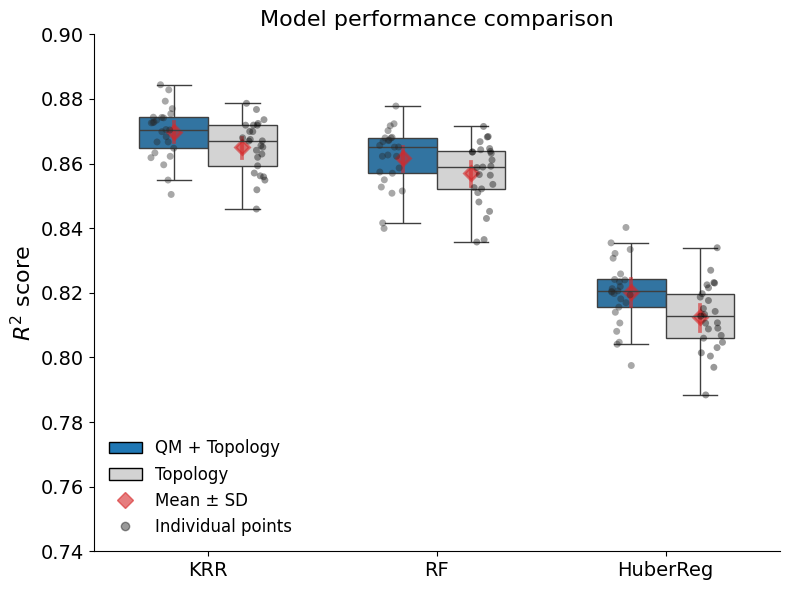

In [25]:
r2_df_relevant = combine_dfs([
        HuberReg_combo_relevant_df,
        HuberReg_topo_relevant_df,
        KRR_combo_relevant_df,
        KRR_topo_relevant_df,
        RF_topo_relevant_df,
        RF_combo_relevant_df
    ])

plot_performance(r2_df_relevant)
plt.tight_layout()
plt.show()

In [48]:
result = (
    r2_df_relevant
    .groupby("name")["test_r2"]
    .agg(["mean", "std"])
    .reset_index()
)
result

,name,mean,std
0,HuberReg_topo+QM_relevant,0.820103,0.010143
1,HuberReg_topo_relevant,0.812379,0.010311
2,KRR_topo+QM_relevant,0.869713,0.008076
3,KRR_topo_relevant,0.865087,0.008102
4,RF_topo+QM_relevant,0.861792,0.009273
5,RF_topo_relevant,0.857068,0.009684


In [26]:
compare(HuberReg_combo_relevant_df, HuberReg_topo_relevant_df, n_train=n_train, n_test=n_test)

HuberReg_topo+QM_relevant mean r2: 0.8201028487096464 (Train: 0.8338952248053524)
HuberReg_topo_relevant mean r2: 0.8123793979340108 (Train: 0.8244105681334191)
Mean improvement: 0.007723450775635525
T-test p-value: 5.651523693472882e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


HuberReg_topo+QM_relevant mean MSE: 0.9577180716971871 (Train: 0.8850710883764441)
HuberReg_topo_relevant mean MSE: 0.9988044718061017 (Train: 0.935602851234462)
Mean improvement: -0.041086400108914525
T-test p-value: 5.7772897577024196e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [27]:
compare(KRR_combo_relevant_df, KRR_topo_relevant_df, n_train=n_train, n_test=n_test)

KRR_topo+QM_relevant mean r2: 0.8697128448843547 (Train: 0.9601237952670004)
KRR_topo_relevant mean r2: 0.865087360456852 (Train: 0.9457995298194344)
Mean improvement: 0.004625484427502862
T-test p-value: 1.0527373173196963e-07 -> statistically significant
Wilcoxon p-value: 1.7881393432617188e-07 -> statistically significant


KRR_topo+QM_relevant mean MSE: 0.6934070625637219 (Train: 0.21246866175530305)
KRR_topo_relevant mean MSE: 0.7179580102923815 (Train: 0.2887941649940877)
Mean improvement: -0.024550947728659553
T-test p-value: 8.457258982019766e-08 -> statistically significant
Wilcoxon p-value: 1.7881393432617188e-07 -> statistically significant




In [28]:
compare(RF_combo_relevant_df, RF_topo_relevant_df, n_train=n_train, n_test=n_test)

RF_topo+QM_relevant mean r2: 0.8617920193529177 (Train: 0.9605397134055772)
RF_topo_relevant mean r2: 0.8570682490878615 (Train: 0.956111952515121)
Mean improvement: 0.004723770265056211
T-test p-value: 7.124878464992435e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


RF_topo+QM_relevant mean MSE: 0.7352821677975894 (Train: 0.21017136281156223)
RF_topo_relevant mean MSE: 0.7603922162750263 (Train: 0.2337468130648199)
Mean improvement: -0.02511004847743712
T-test p-value: 5.700506733319344e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [29]:
huber_data = pd.read_csv(r"..\data\HuberReg_results\1_HuberReg_combo_relevant_rerun_PFI_results.csv")
huber_FI_dict = process_FI_data(huber_data)

huber_FI = FeatureImportance(HuberReg_combo_relevant_df, provided_FI=huber_FI_dict)
huber_fi_df = huber_FI.get_feature_importance(20)



krr_data = pd.read_csv(r"..\data\KRR_results\1_KRR_combo_relevant_rerun_PFI_results.csv")
krr_FI_dict = process_FI_data(krr_data)

krr_FI = FeatureImportance(KRR_combo_relevant_df, provided_FI=krr_FI_dict)
krr_fi_df = krr_FI.get_feature_importance(20)



rf_data = pd.read_csv(r"..\data\RF_results\1_RF_combo_relevant_PFI_results.csv")
rf_FI_dict = process_FI_data(rf_data)

rf_FI = FeatureImportance(RF_combo_relevant_df, provided_FI=rf_FI_dict)
rf_fi_df = rf_FI.get_feature_importance(20)

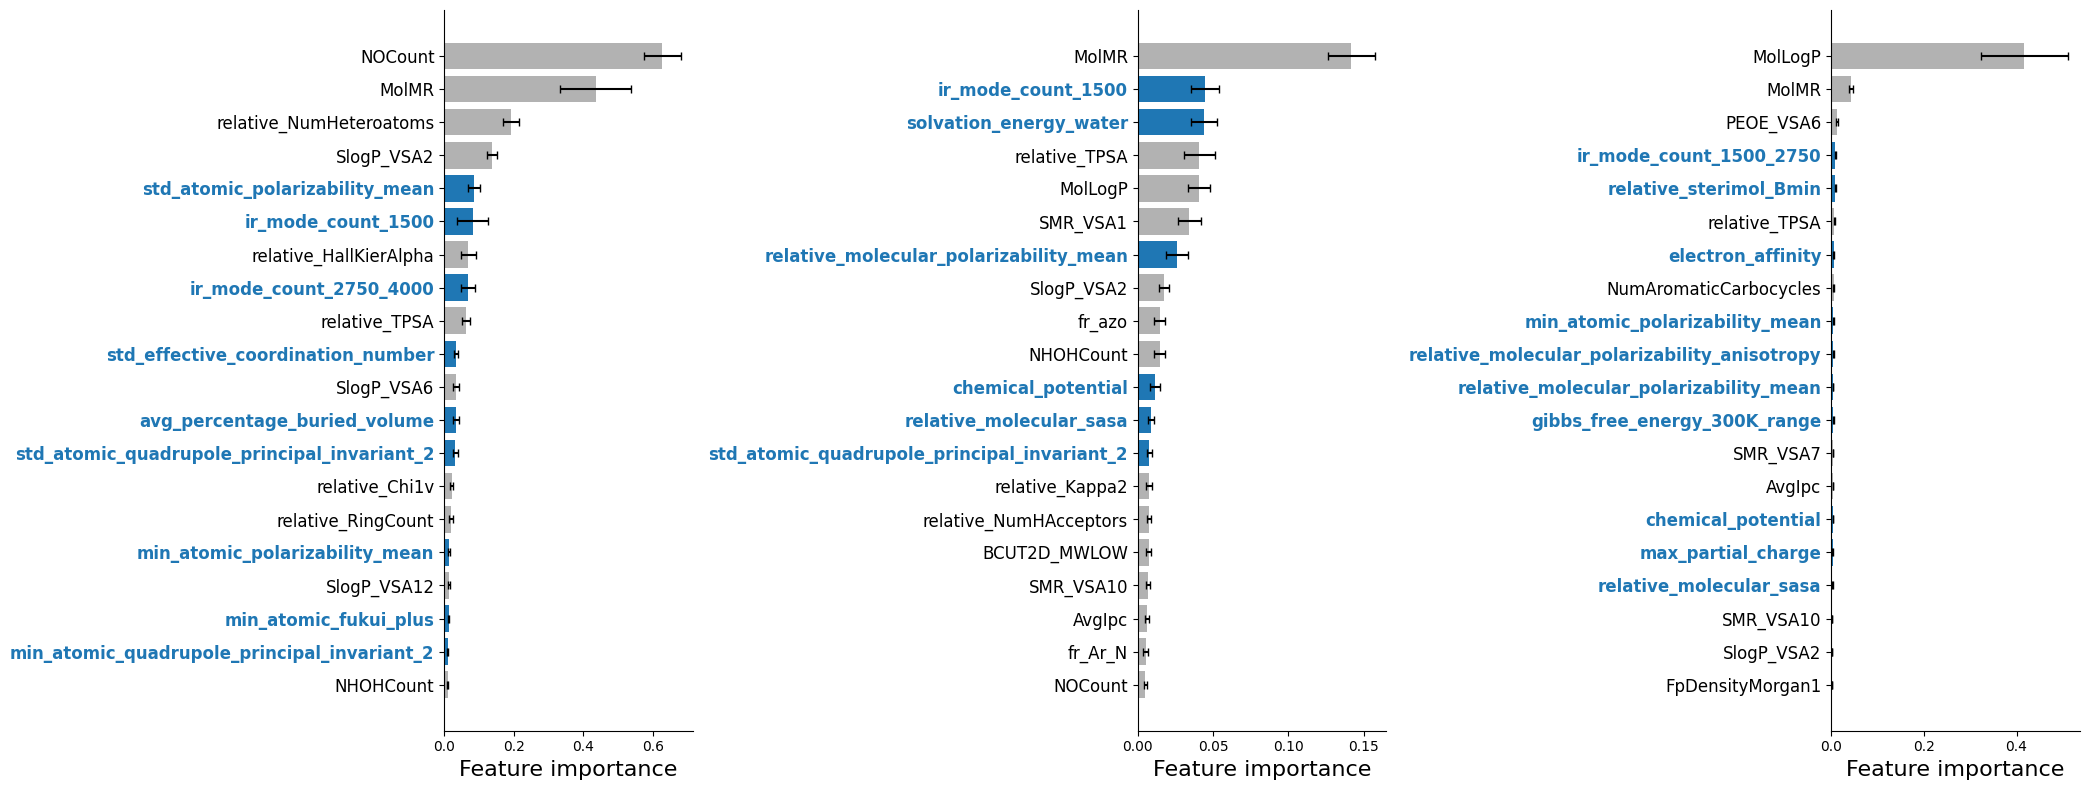

In [30]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 8))

huber_FI.plot(ax1)
krr_FI.plot(ax2)
rf_FI.plot(ax3)

plt.tight_layout()
plt.show()

### Only relevant features, no normalization

In [31]:
HuberReg_combo_relevant_no_norm_df = load_hpc_result(Path("../data/HuberReg_results/1_HuberReg_combo_relevant_no_norm_rerun_results.pkl"), "HuberReg_topo+QM_relevant_no_norm")
HuberReg_topo_relevant_no_norm_df = load_hpc_result(Path("../data/HuberReg_results/1_HuberReg_topo_relevant_no_norm_rerun_results.pkl"), "HuberReg_topo_relevant_no_norm")

In [32]:
KRR_topo_relevant_no_norm_df = load_hpc_result(Path("../data/KRR_results/1_KRR_topo_relevant_no_norm_results.pkl"), "KRR_topo_relevant_no_norm")
KRR_combo_relevant_no_norm_df = load_hpc_result(Path("../data/KRR_results/1_KRR_combo_relevant_no_norm_results.pkl"), "KRR_topo+QM_relevant_no_norm")

In [33]:
RF_topo_relevant_no_norm_df = load_hpc_result(Path("../data/RF_results/1_RF_topo_relevant_no_norm_results.pkl"), "RF_topo_relevant_no_norm")
RF_combo_relevant_no_norm_df = load_hpc_result(Path("../data/RF_results/1_RF_combo_relevant_no_norm_results.pkl"), "RF_topo+QM_relevant_no_norm")

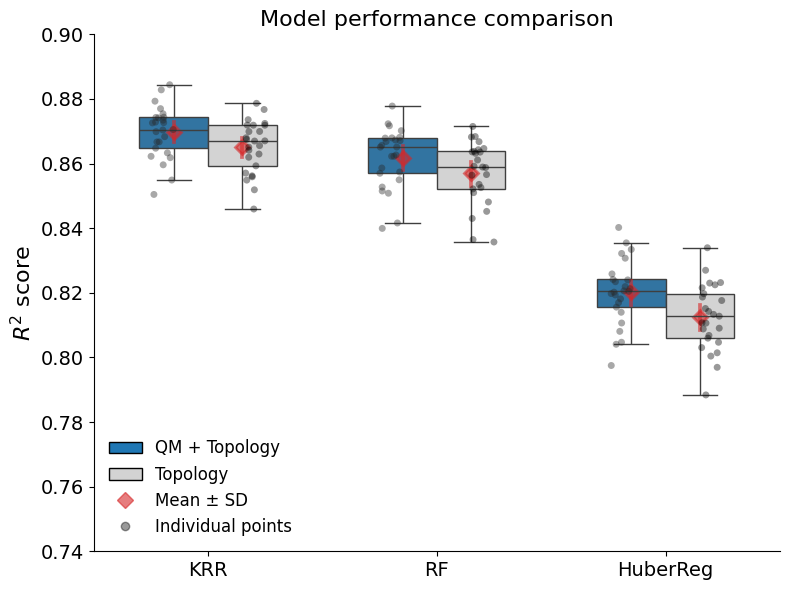

In [34]:
r2_df_relevant = combine_dfs([
        HuberReg_combo_relevant_df,
        HuberReg_topo_relevant_df,
        KRR_combo_relevant_df,
        KRR_topo_relevant_df,
        RF_topo_relevant_df,
        RF_combo_relevant_df
    ])

plot_performance(r2_df_relevant)
plt.tight_layout()
plt.show()

In [35]:
compare(HuberReg_combo_relevant_no_norm_df, HuberReg_topo_relevant_no_norm_df, n_train=n_train, n_test=n_test)

HuberReg_topo+QM_relevant_no_norm mean r2: 0.8219259696325172 (Train: 0.835579938043398)
HuberReg_topo_relevant_no_norm mean r2: 0.8128012132257473 (Train: 0.8246324412032408)
Mean improvement: 0.009124756406769765
T-test p-value: 6.8833827526759706e-15 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


HuberReg_topo+QM_relevant_no_norm mean MSE: 0.9479966184188947 (Train: 0.8760936227215051)
HuberReg_topo_relevant_no_norm mean MSE: 0.9964852384967581 (Train: 0.9344164527831574)
Mean improvement: -0.04848862007786328
T-test p-value: 4.440892098500626e-15 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [36]:
compare(KRR_combo_relevant_no_norm_df, KRR_topo_relevant_no_norm_df, n_train=n_train, n_test=n_test)

KRR_topo+QM_relevant_no_norm mean r2: 0.8676727672452731 (Train: 0.9590745057840283)
KRR_topo_relevant_no_norm mean r2: 0.8626391646541939 (Train: 0.9436110832879282)
Mean improvement: 0.005033602591079207
T-test p-value: 1.6619381284499468e-06 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


KRR_topo+QM_relevant_no_norm mean MSE: 0.7042337971135447 (Train: 0.2179690972865721)
KRR_topo_relevant_no_norm mean MSE: 0.7308407813423643 (Train: 0.3003512857988964)
Mean improvement: -0.026606984228819523
T-test p-value: 8.348763147481009e-07 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [37]:
compare(RF_combo_relevant_no_norm_df, RF_topo_relevant_no_norm_df, n_train=n_train, n_test=n_test)

RF_topo+QM_relevant_no_norm mean r2: 0.8618944455975606 (Train: 0.9600670564255326)
RF_topo_relevant_no_norm mean r2: 0.8566359970813964 (Train: 0.9553701314198504)
Mean improvement: 0.005258448516164171
T-test p-value: 3.275646420775047e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


RF_topo+QM_relevant_no_norm mean MSE: 0.7347735476796824 (Train: 0.21268241062461993)
RF_topo_relevant_no_norm mean MSE: 0.7626977174347204 (Train: 0.23769842713160513)
Mean improvement: -0.027924169755038006
T-test p-value: 2.705768942234954e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [38]:
huber_data = pd.read_csv(r"..\data\HuberReg_results\1_HuberReg_combo_relevant_no_norm_PFI_results.csv")
huber_FI_dict = process_FI_data(huber_data)

huber_FI = FeatureImportance(HuberReg_combo_relevant_no_norm_df, provided_FI=huber_FI_dict)
huber_fi_df = huber_FI.get_feature_importance(20)



krr_data = pd.read_csv(r"..\data\KRR_results\1_KRR_combo_relevant_no_norm_PFI_results.csv")
krr_FI_dict = process_FI_data(krr_data)

krr_FI = FeatureImportance(KRR_combo_relevant_no_norm_df, provided_FI=krr_FI_dict)
krr_fi_df = krr_FI.get_feature_importance(20)



rf_data = pd.read_csv(r"..\data\RF_results\1_RF_combo_relevant_no_norm_PFI_results.csv")
rf_FI_dict = process_FI_data(rf_data)

rf_FI = FeatureImportance(RF_combo_relevant_no_norm_df, provided_FI=rf_FI_dict)
rf_fi_df = rf_FI.get_feature_importance(20)

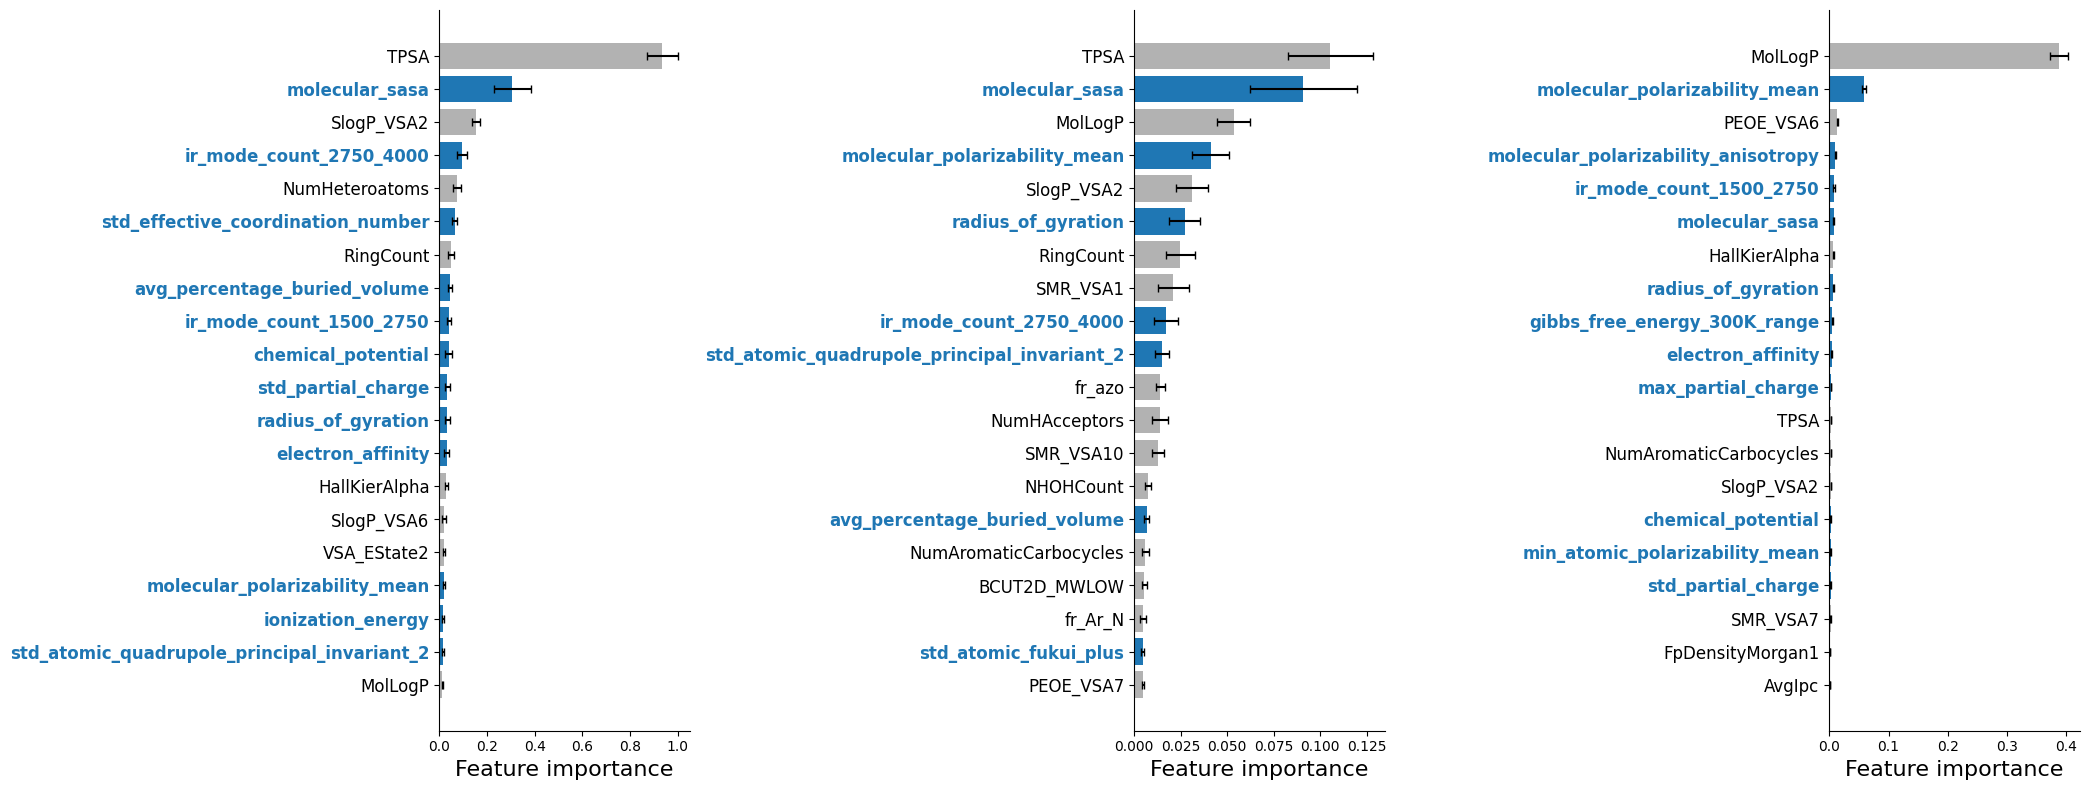

In [39]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 8))

huber_FI.plot(ax1)
krr_FI.plot(ax2)
rf_FI.plot(ax3)

plt.tight_layout()
plt.show()

In [ ]:
# r2_df3 = pd.concat([df[["name", "test_r2"]] for df in [KRR_combo_filtered_df, KRR_topo_filtered_df, KRR_topo_relevant_df, KRR_combo_relevant_df, KRR_combo_relevant_no_norm_df, KRR_topo_relevant_no_norm_df]])

# r2_df3["group"] = r2_df3["name"].str.extract(r"(filtered|relevant|norm)$")
# r2_df3["variant"] = r2_df3["name"].str.extract(r"_(topo\+QM|topo)")

# r2_df3["variant"] = r2_df3["variant"].replace({
#     "topo": "Topo",
#     "topo+QM": "Topo+QM"
# })

In [23]:
order = (
    r2_df3.groupby("group")["test_r2"]
    .mean()
    .sort_values(ascending=False)
    .index
)
order

Index(['relevant', 'norm', 'filtered'], dtype='str', name='group')

In [25]:
# compute mean per group
df_mean = (
    r2_df
    .groupby(["group", "variant"])["test_r2"]
    .mean()
    .unstack()
    .reset_index()
)
df_mean

variant,group,Topo,Topo+QM
0,HuberReg,0.815978,0.822347
1,KRR,0.861859,0.866426
2,RF,0.856421,0.861942


In [26]:
# compute mean per group
df_mean = (
    r2_df2
    .groupby(["group", "variant"])["test_r2"]
    .mean()
    .unstack()
    .reset_index()
)
df_mean

variant,group,Topo,Topo+QM
0,HuberReg,0.813662,0.821458
1,KRR,0.864710,0.868353
2,RF,0.856421,0.861942


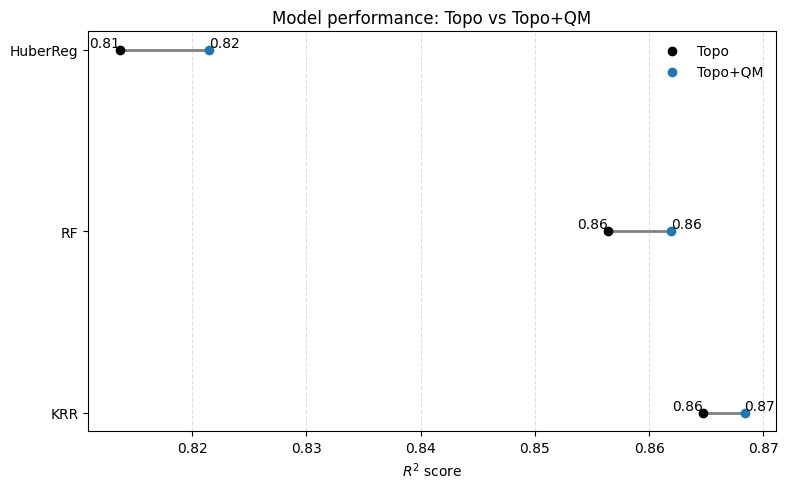

In [27]:
plt.figure(figsize=(8, 5))

# sort models by improvement (optional but nice)
df_mean["diff"] = df_mean["Topo+QM"] - df_mean["Topo"]
df_mean = df_mean.sort_values("diff")

y_pos = range(len(df_mean))

# draw lines (the "dumbbell sticks")
for i, row in enumerate(df_mean.itertuples()):
    plt.plot(
        [row.Topo, row._3],  # _3 = Topo+QM column
        [i, i],
        color="gray",
        linewidth=2,
        zorder=1
    )

# draw endpoints
plt.scatter(df_mean["Topo"], y_pos, color="black", label="Topo", zorder=2)
plt.scatter(df_mean["Topo+QM"], y_pos, color="tab:blue", label="Topo+QM", zorder=3)

for i, row in enumerate(df_mean.itertuples()):
    plt.text(row.Topo, i, f"{row.Topo:.2f}", va="bottom", ha="right")
    plt.text(row._3, i, f"{row._3:.2f}", va="bottom", ha="left")

# labels
plt.yticks(y_pos, df_mean["group"])
plt.xlabel(r"$R^2$ score")
plt.title("Model performance: Topo vs Topo+QM")

plt.legend(frameon=False)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()